In [1]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
#===========================================
# Load File 1
#===========================================

with open('Sample_Gaussian_BIS_MMD.npy', 'rb') as f:
    sample_losses_01_bis = jnp.load(f)
    
with open('Sample_Gaussian_QMC_MMD.npy', 'rb') as f:
    sample_losses_01_qmc = jnp.load(f)
    
with open('Sample_Bimodal_BIS_MMD.npy', 'rb') as f:
    sample_losses_02_bis = jnp.load(f)
    
with open('Sample_Bimodal_QMC_MMD.npy', 'rb') as f:
    sample_losses_02_qmc = jnp.load(f)
    
with open('Sample_Banana_BIS_MMD.npy', 'rb') as f:
    sample_losses_03_bis = jnp.load(f)

with open('Sample_Banana_QMC_MMD.npy', 'rb') as f:
    sample_losses_03_qmc = jnp.load(f)

sample_losses_01_list = [ sample_losses_01_bis, sample_losses_01_qmc ]
sample_losses_02_list = [ sample_losses_02_bis, sample_losses_02_qmc ]
sample_losses_03_list = [ sample_losses_03_bis, sample_losses_03_qmc ]


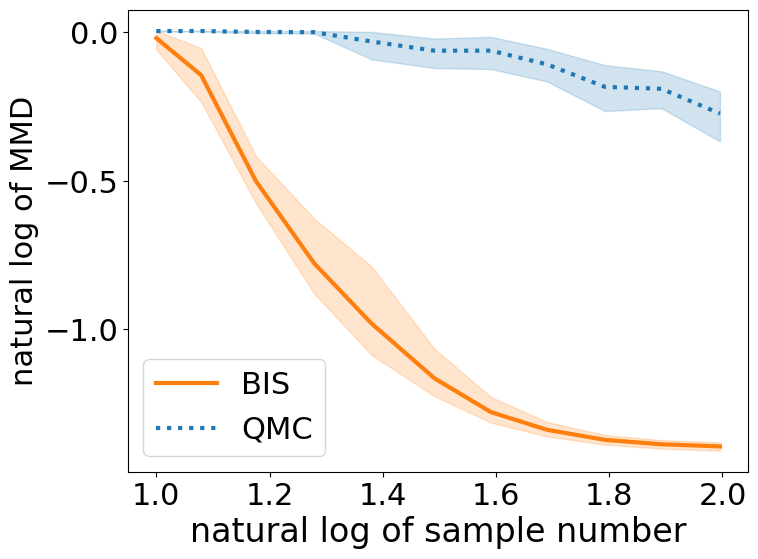

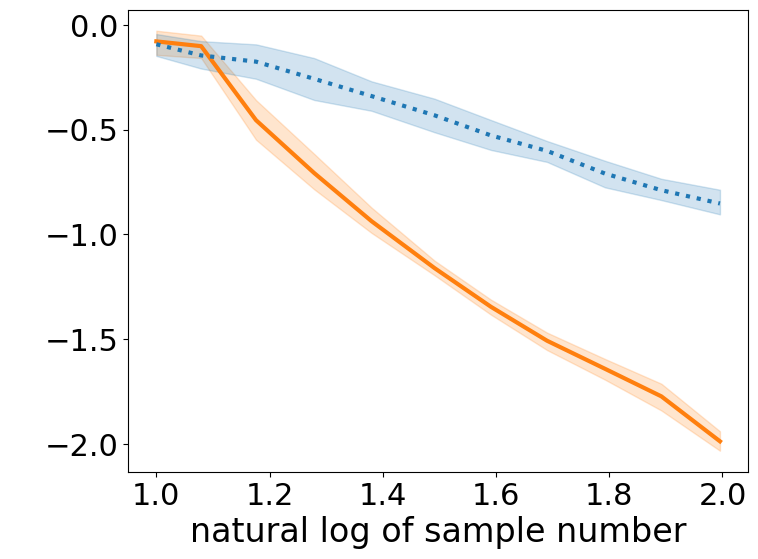

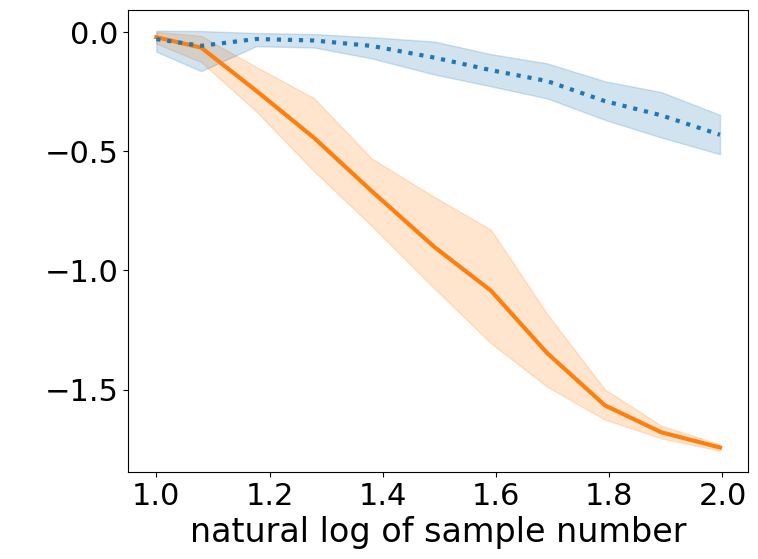

In [3]:
#===========================================
# Visualise Sample Losses
#===========================================

def plot_sample_loss(loss_list, init_num=10, total_num=100, ytick=None, xlabel=True, ylabel=True, legend=True):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    loss_index = jnp.log10( jnp.array([10, 12, 15, 19, 24, 31, 39, 49, 62, 78, 99]) )
    df_bis = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[0].flatten())})
    df_qmc = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[1].flatten())})

    sns.lineplot(df_bis, x='index', y='loss', ax=ax, color=sns.color_palette()[1], linestyle='solid', linewidth=3, label="BIS")
    sns.lineplot(df_qmc, x='index', y='loss', ax=ax, color=sns.color_palette()[0], linestyle='dotted', linewidth=3, label="QMC")

    if ytick:
        ax.set_yticks(ytick)
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.set_xlabel("natural log of sample number", fontsize=24) if xlabel else ax.set_xlabel(" ", fontsize=22)
    ax.set_ylabel("natural log of MMD", fontsize=22) if ylabel else ax.set_ylabel(" ", fontsize=22)
    ax.legend(prop=dict(size=22)) if legend else ax.get_legend().remove()

plot_sample_loss(sample_losses_01_list, ytick=[0.0, -0.5, -1.0])
plot_sample_loss(sample_losses_02_list, ytick=[0.0, -0.5, -1.0, -1.5, -2.0], ylabel=False, legend=False)
plot_sample_loss(sample_losses_03_list, ytick=[0.0, -0.5, -1.0, -1.5], ylabel=False, legend=False)


In [4]:
#===========================================
# Load File 2
#===========================================

with open('GP_Gaussian_BIS_TVD.npy', 'rb') as f:
    gp_losses_01_bis = jnp.load(f)
    
with open('GP_Gaussian_QMC_TVD.npy', 'rb') as f:
    gp_losses_01_qmc = jnp.load(f)
    
with open('GP_Gaussian_RBO_TVD.npy', 'rb') as f:
    gp_losses_01_rbo = jnp.load(f)

with open('GP_Gaussian_EIV_TVD.npy', 'rb') as f:
    gp_losses_01_eiv = jnp.load(f)
    

with open('GP_Bimodal_BIS_TVD.npy', 'rb') as f:
    gp_losses_02_bis = jnp.load(f)
    
with open('GP_Bimodal_QMC_TVD.npy', 'rb') as f:
    gp_losses_02_qmc = jnp.load(f)
    
with open('GP_Bimodal_RBO_TVD.npy', 'rb') as f:
    gp_losses_02_rbo = jnp.load(f)
    
with open('GP_Bimodal_EIV_TVD.npy', 'rb') as f:
    gp_losses_02_eiv = jnp.load(f)

    
with open('GP_Banana_BIS_TVD.npy', 'rb') as f:
    gp_losses_03_bis = jnp.load(f)

with open('GP_Banana_QMC_TVD.npy', 'rb') as f:
    gp_losses_03_qmc = jnp.load(f)

with open('GP_Banana_RBO_TVD.npy', 'rb') as f:
    gp_losses_03_rbo = jnp.load(f)
    
with open('GP_Banana_EIV_TVD.npy', 'rb') as f:
    gp_losses_03_eiv = jnp.load(f)

    
gp_losses_01_list = [ gp_losses_01_bis, gp_losses_01_qmc, gp_losses_01_rbo, gp_losses_01_eiv ]
gp_losses_02_list = [ gp_losses_02_bis, gp_losses_02_qmc, gp_losses_02_rbo, gp_losses_02_eiv ]
gp_losses_03_list = [ gp_losses_03_bis, gp_losses_03_qmc, gp_losses_03_rbo, gp_losses_03_eiv ]


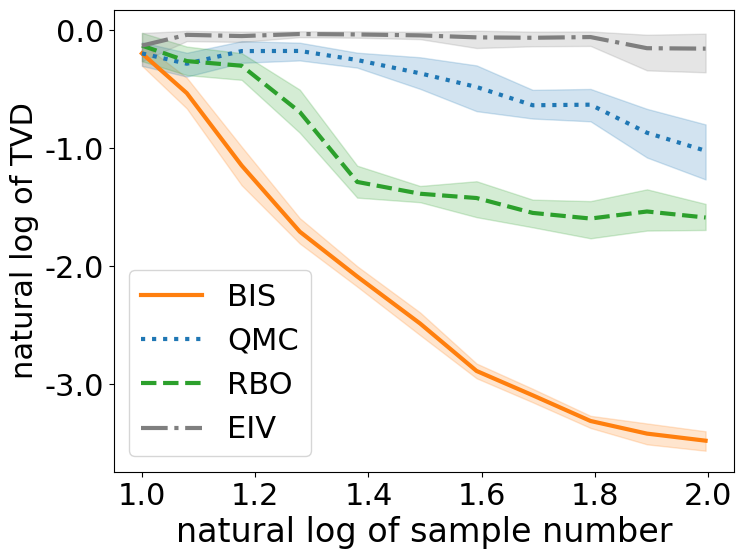

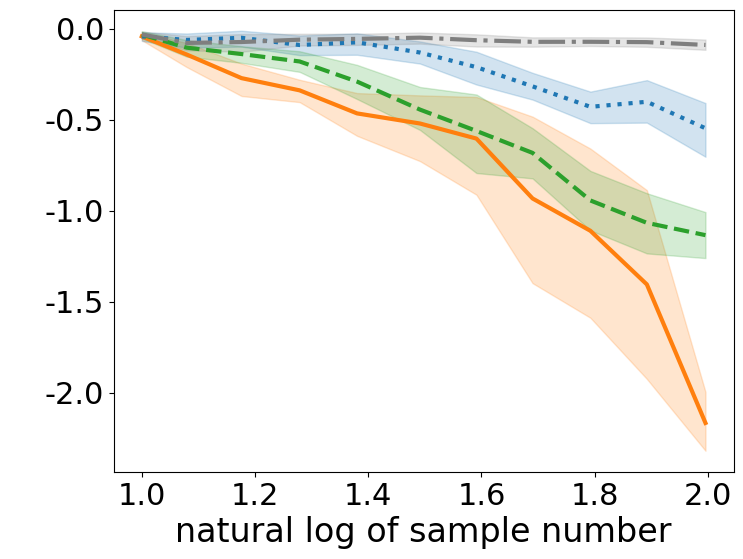

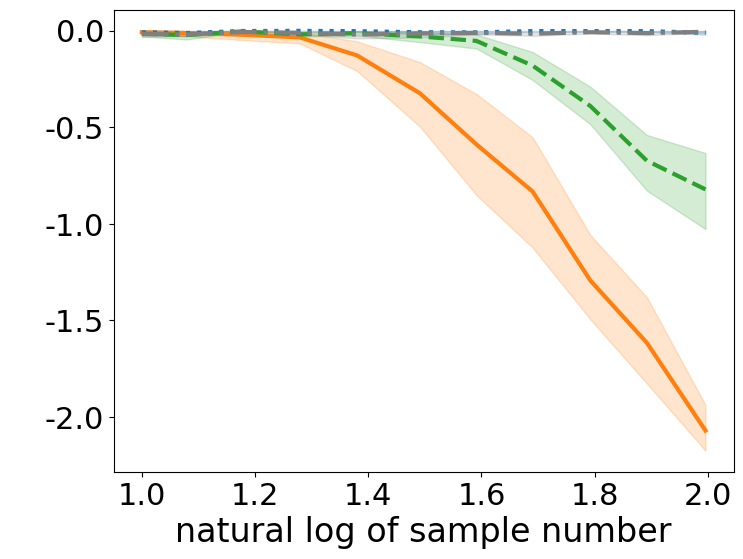

In [5]:
#===========================================
# Visualise Approx Losses
#===========================================
from matplotlib.ticker import FormatStrFormatter

def plot_approx_loss(loss_list, init_num=10, total_num=100, ytick=None, xlabel=True, ylabel=True, legend=True):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    loss_index = jnp.log10( jnp.array([10, 12, 15, 19, 24, 31, 39, 49, 62, 78, 99]) )
    df_bis = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[0].flatten())})
    df_qmc = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[1].flatten())})
    df_rbo = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[2].flatten())})
    df_eiv = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[3].flatten())})

    sns.lineplot(df_bis, x='index', y='loss', ax=ax, color=sns.color_palette()[1], linestyle='solid', linewidth=3, label="BIS")
    sns.lineplot(df_qmc, x='index', y='loss', ax=ax, color=sns.color_palette()[0], linestyle='dotted', linewidth=3, label="QMC")
    sns.lineplot(df_rbo, x='index', y='loss', ax=ax, color=sns.color_palette()[2], linestyle='dashed', linewidth=3, label="RBO")
    sns.lineplot(df_eiv, x='index', y='loss', ax=ax, color=sns.color_palette()[7], linestyle='dashdot', linewidth=3, label="EIV")
    
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.set_xlabel("natural log of sample number", fontsize=24) if xlabel else ax.set_xlabel(" ", fontsize=22)
    ax.set_ylabel("natural log of TVD", fontsize=22) if ylabel else ax.set_ylabel(" ", fontsize=22)
    ax.legend(prop=dict(size=22)) if legend else ax.get_legend().remove()
    
plot_approx_loss(gp_losses_01_list, ytick=[0.0, -0.5, -1.0, -1.5, -2.0, -2.5, -3.0, -3.5])
plot_approx_loss(gp_losses_02_list, ytick=[0.0, -0.5, -1.0, -1.5, -2.0, -2.5], ylabel=False, legend=False)
plot_approx_loss(gp_losses_03_list, ytick=[0.0, -0.5, -1.0, -1.5, -2.0], ylabel=False, legend=False)
